<a href="https://colab.research.google.com/github/Simbab13/CHEM5610-Final-ScottWatson/blob/main/FinalModel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Final assignment**

**Student Name(s)**: Scott Watson

**AI usage statement:**
No AI used. Citation list:
1. [Help in fixing an error with pytorch](https://stackoverflow.com/questions/66679163/pytorch-cant-find-the-name-nameerror-name-device-is-not-defined)
2. [What a learning rate is](https://www.geeksforgeeks.org/machine-learning/impact-of-learning-rate-on-a-model/)
3. [RDKit documentation for heavy atom count check](https://www.rdkit.org/docs/source/rdkit.Chem.rdMolDescriptors.html)

In [1]:
import sys
IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    !pip install rdkit torch_geometric lightgbm mols2grid

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.0/37.0 MB 39.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 45.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 83.5/83.5 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 69.2 MB/s eta 0:00:00


In [2]:

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from rdkit import Chem
from rdkit.Chem import rdMolDescriptors

from tqdm.auto import tqdm

from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.inspection import permutation_importance
from sklearn.ensemble import RandomForestRegressor

# LightGBM
from lightgbm import LGBMRegressor, plot_importance

tqdm.pandas()

In [3]:
#get the database
import torch
from torch_geometric.datasets import QM9
from torch_geometric.data import Data

In [4]:
%%bash
wget https://deepchemdata.s3.us-west-1.amazonaws.com/datasets/qm9.tar.gz
tar xvf qm9.tar.gz

qm9.sdf
qm9.sdf.csv


--2026-05-04 21:12:28--  https://deepchemdata.s3.us-west-1.amazonaws.com/datasets/qm9.tar.gz
Resolving deepchemdata.s3.us-west-1.amazonaws.com (deepchemdata.s3.us-west-1.amazonaws.com)... 16.15.0.227, 16.15.0.18, 52.219.194.162, ...
Connecting to deepchemdata.s3.us-west-1.amazonaws.com (deepchemdata.s3.us-west-1.amazonaws.com)|16.15.0.227|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 53359625 (51M) [application/x-gzip]
Saving to: ‘qm9.tar.gz’

     0K .......... .......... .......... .......... ..........  0%  286K 3m2s
    50K .......... .......... .......... .......... ..........  0%  286K 3m2s
   100K .......... .......... .......... .......... ..........  0%  287K 3m1s
   150K .......... .......... .......... .......... ..........  0%  107M 2m16s
   200K .......... .......... .......... .......... ..........  0% 61.5M 1m49s
   250K .......... .......... .......... .......... ..........  0%  288K 2m1s
   300K .......... .......... .......... .......... ..

In [5]:
molecules = Chem.SDMolSupplier('qm9.sdf', removeHs=False,
                                   sanitize=False)
data = pd.read_csv("qm9.sdf.csv")

In [6]:
data

,mol_id,A,B,C,mu,alpha,homo,lumo,gap,r2,zpve,u0,u298,h298,g298,cv,u0_atom,u298_atom,h298_atom,g298_atom
0,gdb_1,157.71180,157.709970,157.706990,0.0000,13.21,-0.3877,0.1171,0.5048,35.3641,0.044749,-40.478930,-40.476062,-40.475117,-40.498597,6.469,-395.999595,-398.643290,-401.014647,-372.471772
1,gdb_2,293.60975,293.541110,191.393970,1.6256,9.46,-0.2570,0.0829,0.3399,26.1563,0.034358,-56.525887,-56.523026,-56.522082,-56.544961,6.316,-276.861363,-278.620271,-280.399259,-259.338802
2,gdb_3,799.58812,437.903860,282.945450,1.8511,6.31,-0.2928,0.0687,0.3615,19.0002,0.021375,-76.404702,-76.401867,-76.400922,-76.422349,6.002,-213.087624,-213.974294,-215.159658,-201.407171
3,gdb_4,0.00000,35.610036,35.610036,0.0000,16.28,-0.2845,0.0506,0.3351,59.5248,0.026841,-77.308427,-77.305527,-77.304583,-77.327429,8.574,-385.501997,-387.237686,-389.016047,-365.800724
4,gdb_5,0.00000,44.593883,44.593883,2.8937,12.99,-0.3604,0.0191,0.3796,48.7476,0.016601,-93.411888,-93.409370,-93.408425,-93.431246,6.278,-301.820534,-302.906752,-304.091489,-288.720028
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
133880,gdb_133881,3.59483,2.198990,1.904230,1.6637,69.37,-0.2254,0.0588,0.2842,760.7472,0.127406,-400.633868,-400.628599,-400.627654,-400.663098,23.658,-1603.983913,-1614.898804,-1623.788097,-1492.819438
133881,gdb_133882,3.65648,2.142370,1.904390,1.2976,69.52,-0.2393,0.0608,0.3002,762.6354,0.127495,-400.629713,-400.624444,-400.623500,-400.658942,23.697,-1601.376613,-1612.291504,-1621.181424,-1490.211511
133882,gdb_133883,3.67118,2.143140,1.895010,1.2480,73.60,-0.2233,0.0720,0.2953,780.3553,0.140458,-380.753918,-380.748619,-380.747675,-380.783148,23.972,-1667.045429,-1678.830048,-1688.312964,-1549.143391
133883,gdb_133884,3.52845,2.151310,1.865820,1.9576,77.40,-0.2122,0.0881,0.3003,803.1904,0.152222,-364.720374,-364.714974,-364.714030,-364.749650,24.796,-1794.600439,-1807.210860,-1817.286772,-1670.349892


In [7]:
gap = data.keys()[8]
homo = data.keys()[6]
lumo = data.keys()[7]

In [8]:
def visualize_rdkit_mol_2d(mol):
  from rdkit.Chem.Draw import MolToImage
  from rdkit import Chem
  from rdkit.Chem import rdDepictor

  # Attempt to sanitize and kekulize the molecule for better depiction
  # It's good practice to make a copy if you don't want to modify the original supplier object's molecule
  sanitized_mol = Chem.Mol(mol) # Create a copy
  try:
      Chem.SanitizeMol(sanitized_mol)
      # Kekulize for clearer ring depictions, if applicable
      Chem.Kekulize(sanitized_mol)
  except Exception as e:
      print(f"Warning: Could not sanitize or kekulize molecule at index {mol_index}: {e}")
      sanitized_mol = mol # Fallback to original if sanitization fails

  # Compute 2D coordinates for the (potentially) sanitized molecule
  rdDepictor.Compute2DCoords(sanitized_mol)

  # Visualize the molecule
  img = MolToImage(sanitized_mol, size=(300, 300))
  display(img)

In [9]:
property_names = list(rdMolDescriptors.Properties.GetAvailableProperties())
property_getter = rdMolDescriptors.Properties(property_names)
def mol2props(mol):
    if mol:
        props = np.array(property_getter.ComputeProperties(mol))
        if len(props) != len(property_names):
          props = np.array(len(property_names)*[np.nan])
    else:
      props = np.array(len(property_names)*[np.nan])
    return props

In [10]:
#@title Define Features
ATOM_FEATURES = {
    "atomic_num":       [1,6,7,8,9],
    "degree":           list(range(0, 5)),
    "formal_charge":    [0],
    "chiral_tag":       list(range(0,3)),
    "num_Hs":           [0],
    "hybridization":    [
        Chem.rdchem.HybridizationType.SP,
        Chem.rdchem.HybridizationType.SP2,
        Chem.rdchem.HybridizationType.SP3,
        Chem.rdchem.HybridizationType.SP3D,
        Chem.rdchem.HybridizationType.SP3D2,
    ],
}

BOND_FEATURES = {
    "bond_type": [
        Chem.rdchem.BondType.SINGLE,
        Chem.rdchem.BondType.DOUBLE,
        Chem.rdchem.BondType.TRIPLE,
        Chem.rdchem.BondType.AROMATIC,
    ],
    "stereo": list(range(6)),
    "is_conjugated": [False, True],
    "is_in_ring":    [False, True],
}


def one_hot(value, choices):
    """One-hot encode a value; unknown → all-zeros."""
    encoding = [0] * (len(choices) + 1)
    idx = choices.index(value) if value in choices else len(choices)
    encoding[idx] = 1
    return encoding


def atom_features(atom) -> list:
    feats = []
    feats += one_hot(atom.GetAtomicNum(),       ATOM_FEATURES["atomic_num"])
    feats += one_hot(atom.GetDegree(),           ATOM_FEATURES["degree"])
    #feats += one_hot(atom.GetFormalCharge(),     ATOM_FEATURES["formal_charge"])
    feats += one_hot(int(atom.GetChiralTag()),   ATOM_FEATURES["chiral_tag"])
    feats += one_hot(atom.GetTotalNumHs(),       ATOM_FEATURES["num_Hs"])
    feats += one_hot(atom.GetHybridization(),    ATOM_FEATURES["hybridization"])
    feats.append(int(atom.GetIsAromatic()))
    feats.append(atom.GetMass() / 100.0)        # scaled mass
    return feats


def bond_features(bond) -> list:
    feats = []
    feats += one_hot(bond.GetBondType(),         BOND_FEATURES["bond_type"])
    feats += one_hot(int(bond.GetStereo()),      BOND_FEATURES["stereo"])
    feats += one_hot(bond.GetIsConjugated(),     BOND_FEATURES["is_conjugated"])
    feats += one_hot(bond.IsInRing(),            BOND_FEATURES["is_in_ring"])
    return feats

def mol_to_graph(mol, y=None):

    if mol is None:
        return None

    # Atom features
    x = torch.tensor(
        [atom_features(a) for a in mol.GetAtoms()], dtype=torch.float
    )

    # Bond features (undirected => two directed edges per bond)
    edge_index, edge_attr = [], []
    for bond in mol.GetBonds():
        i, j = bond.GetBeginAtomIdx(), bond.GetEndAtomIdx()
        bf = bond_features(bond)
        edge_index += [[i, j], [j, i]]
        edge_attr  += [bf, bf]

    if len(edge_index) == 0:
        edge_index = torch.zeros((2, 0), dtype=torch.long)
        edge_attr  = torch.zeros((0, len(bond_features(
            mol.GetBondWithIdx(0)
        ))), dtype=torch.float) if mol.GetNumBonds() > 0 else torch.zeros((0, 14), dtype=torch.float)
    else:
        edge_index = torch.tensor(edge_index, dtype=torch.long).t().contiguous()
        edge_attr  = torch.tensor(edge_attr,  dtype=torch.float)

    data = Data(x=x, edge_index=edge_index, edge_attr=edge_attr)
    if y is not None:
        data.y = torch.tensor([y], dtype=torch.float)
    return data

In [11]:
mol_index = 1
g = mol_to_graph(molecules[mol_index])
print(g)

Data(x=[4, 26], edge_index=[2, 6], edge_attr=[6, 18])


In [12]:
#@title Setup Visualization tools
def visualize_graph(mol_graph):
  from torch_geometric.utils import to_networkx
  import networkx as nx
  import matplotlib.pyplot as plt
  import torch

  data_instance = mol_graph

  # Convert the PyG graph to a NetworkX graph
  G = to_networkx(data_instance, to_undirected=True)

  # Define mapping for atomic numbers to element symbols
  atomic_number_map = {
      1: 'H', 2: 'He', 3: 'Li', 4: 'Be', 5: 'B',
      6: 'C', 7: 'N', 8: 'O', 9: 'F', 14: 'Si', 15: 'P',
      16: 'S', 17: 'Cl', 35: 'Br', 53: 'I'
  }

  # Prepare node labels (atom types)
  node_labels = {}
  # The length of the one-hot vector for atomic_num is len(ATOM_FEATURES["atomic_num"]) + 1
  atomic_num_choices = ATOM_FEATURES["atomic_num"]
  one_hot_vec_len = len(atomic_num_choices) + 1

  for i, node_features_tensor in enumerate(data_instance.x):
      # Extract the one-hot encoded atomic number part
      atomic_num_one_hot_vector = node_features_tensor[:one_hot_vec_len]

      # Find the index of the '1' in the one-hot vector
      atomic_num_idx = torch.argmax(atomic_num_one_hot_vector).item()

      # Convert the index back to the actual atomic number
      if atomic_num_idx < len(atomic_num_choices):
          atomic_num = atomic_num_choices[atomic_num_idx]
      else:
          # This means the atomic number was not in the choices list (e.g., if one_hot encoded it as 'unknown')
          atomic_num = 0 # Represent as unknown or fallback

      node_labels[i] = atomic_number_map.get(atomic_num, f'Unknown({atomic_num})')

  # Define mapping for edge attributes (bond types)
  # Assuming edge_attr is a one-hot encoding for [single, double, triple, aromatic]
  bond_type_map = {
      0: 'single',
      1: 'double',
      2: 'triple',
      3: 'aromatic'
  }

  # Prepare edge labels
  edge_labels = {}
  # Iterate through the original PyG edge_index and edge_attr to get labels
  # edge_index.t() transposes (2, num_edges) to (num_edges, 2) for easier iteration
  for i, (u, v) in enumerate(data_instance.edge_index.t().tolist()):
      # Get the one-hot encoded attribute vector for the current edge
      attr_vector = data_instance.edge_attr[i]

      # Determine the bond type from the one-hot vector
      # Only process if the vector has a '1' (i.e., it's a valid one-hot)
      if attr_vector.sum() > 0:
          bond_type_idx = torch.argmax(attr_vector).item()
          label = bond_type_map.get(bond_type_idx, f"type_{bond_type_idx}")
      else:
          label = "unknown" # Fallback for unexpected attribute vectors

      # Add the label to the dictionary. NetworkX's draw_networkx_edge_labels
      # will correctly match this label to the undirected edge in G.
      # We'll add it for the (u, v) pair as it appears in edge_index.
      edge_labels[(u, v)] = label


  plt.figure(figsize=(6, 6)) # Make figure slightly larger to accommodate labels
  pos = nx.spring_layout(G, seed=42) # Use a fixed seed for reproducible layout

  # Draw nodes and edges
  nx.draw_networkx(G, pos,
                  labels=node_labels, # Use atom types as node labels
                  node_color='skyblue',
                  node_size=700, # Slightly larger nodes
                  font_size=10,
                  font_weight='bold',
                  width=1.5) # Slightly thicker edges

  # Draw edge labels
  nx.draw_networkx_edge_labels(G, pos,
                                edge_labels=edge_labels,
                                font_color='red',
                                font_size=8)

  plt.title(f"Graph Visualization")
  plt.axis('off') # Hide axes for cleaner look
  plt.show()

In [13]:
#@title Prepare parameter lists for GNN
mol_gap_graphs = []
for i, mol in enumerate(tqdm(molecules)):
    g = mol_to_graph(mol, y=data.iloc[i][gap])
    if g:
      mol_gap_graphs.append(g)

mol_homo_graphs = []
for i, mol in enumerate(tqdm(molecules)):
    g = mol_to_graph(mol, y=data.iloc[i][homo])
    if g:
      mol_homo_graphs.append(g)

mol_lumo_graphs = []
for i, mol in enumerate(tqdm(molecules)):
    g = mol_to_graph(mol, y=data.iloc[i][lumo])
    if g:
      mol_lumo_graphs.append(g)

  0%|          | 0/133885 [00:00<?, ?it/s]

[21:12:41] Both bonds on one end of an atropisomer are on the same side - atoms are: 2 1
[21:13:00] The 2 defining bonds for an atropisomer are co-planar - atoms are: 4 2
[21:13:40] The 2 defining bonds for an atropisomer are co-planar - atoms are: 4 5
[21:13:40] The 2 defining bonds for an atropisomer are co-planar - atoms are: 6 5
[21:13:42] The 2 defining bonds for an atropisomer are co-planar - atoms are: 1 3
[21:13:47] Both bonds on one end of an atropisomer are on the same side - atoms are: 1 8
[21:13:47] Both bonds on one end of an atropisomer are on the same side - atoms are: 1 8
[21:13:47] Both bonds on one end of an atropisomer are on the same side - atoms are: 1 8
[21:13:53] Both bonds on one end of an atropisomer are on the same side - atoms are: 7 1
[21:13:59] The 2 defining bonds for an atropisomer are co-planar - atoms are: 4 6
[21:14:43] The 2 defining bonds for an atropisomer are co-planar - atoms are: 2 7


  0%|          | 0/133885 [00:00<?, ?it/s]

[21:14:49] Both bonds on one end of an atropisomer are on the same side - atoms are: 2 1
[21:15:09] The 2 defining bonds for an atropisomer are co-planar - atoms are: 4 2
[21:15:48] The 2 defining bonds for an atropisomer are co-planar - atoms are: 4 5
[21:15:48] The 2 defining bonds for an atropisomer are co-planar - atoms are: 6 5
[21:15:50] The 2 defining bonds for an atropisomer are co-planar - atoms are: 1 3
[21:15:56] Both bonds on one end of an atropisomer are on the same side - atoms are: 1 8
[21:15:56] Both bonds on one end of an atropisomer are on the same side - atoms are: 1 8
[21:15:56] Both bonds on one end of an atropisomer are on the same side - atoms are: 1 8
[21:16:01] Both bonds on one end of an atropisomer are on the same side - atoms are: 7 1
[21:16:08] The 2 defining bonds for an atropisomer are co-planar - atoms are: 4 6
[21:16:52] The 2 defining bonds for an atropisomer are co-planar - atoms are: 2 7


  0%|          | 0/133885 [00:00<?, ?it/s]

[21:16:59] Both bonds on one end of an atropisomer are on the same side - atoms are: 2 1
[21:17:18] The 2 defining bonds for an atropisomer are co-planar - atoms are: 4 2
[21:17:57] The 2 defining bonds for an atropisomer are co-planar - atoms are: 4 5
[21:17:57] The 2 defining bonds for an atropisomer are co-planar - atoms are: 6 5
[21:18:00] The 2 defining bonds for an atropisomer are co-planar - atoms are: 1 3
[21:18:06] Both bonds on one end of an atropisomer are on the same side - atoms are: 1 8
[21:18:06] Both bonds on one end of an atropisomer are on the same side - atoms are: 1 8
[21:18:06] Both bonds on one end of an atropisomer are on the same side - atoms are: 1 8
[21:18:11] Both bonds on one end of an atropisomer are on the same side - atoms are: 7 1
[21:18:18] The 2 defining bonds for an atropisomer are co-planar - atoms are: 4 6
[21:19:01] The 2 defining bonds for an atropisomer are co-planar - atoms are: 2 7


In [14]:
#@title Prepare Parameter list for LightGBM
props = []
for i, mol in enumerate(tqdm(molecules)):
  prop = mol2props(mol)
  props.append(prop)

  0%|          | 0/133885 [00:00<?, ?it/s]

[21:19:12] Both bonds on one end of an atropisomer are on the same side - atoms are: 2 1
[21:20:01] The 2 defining bonds for an atropisomer are co-planar - atoms are: 4 2
[21:21:43] The 2 defining bonds for an atropisomer are co-planar - atoms are: 4 5
[21:21:43] The 2 defining bonds for an atropisomer are co-planar - atoms are: 6 5
[21:21:52] The 2 defining bonds for an atropisomer are co-planar - atoms are: 1 3
[21:22:09] Both bonds on one end of an atropisomer are on the same side - atoms are: 1 8
[21:22:09] Both bonds on one end of an atropisomer are on the same side - atoms are: 1 8
[21:22:09] Both bonds on one end of an atropisomer are on the same side - atoms are: 1 8
[21:22:25] Both bonds on one end of an atropisomer are on the same side - atoms are: 7 1
[21:22:45] The 2 defining bonds for an atropisomer are co-planar - atoms are: 4 6
[21:24:29] The 2 defining bonds for an atropisomer are co-planar - atoms are: 2 7


In [15]:
indices = [i for i, x in enumerate(props) if x is None]
print(indices)
for idx in indices:
  props[idx] = np.array(len(property_names)*[np.nan])

[]


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003259 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 765
[LightGBM] [Info] Number of data points in the train set: 107108, number of used features: 3
[LightGBM] [Info] Start training from score -0.240005


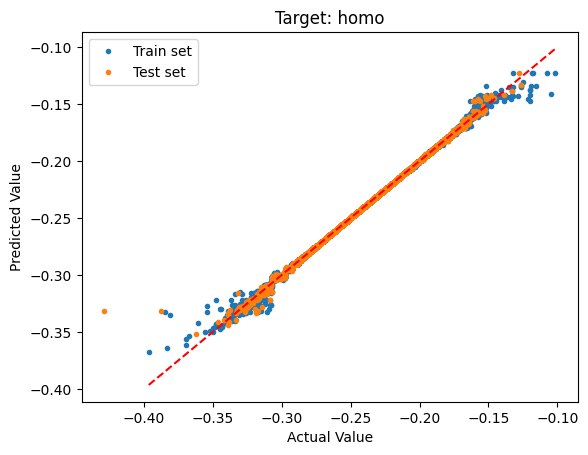

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002921 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 765
[LightGBM] [Info] Number of data points in the train set: 107108, number of used features: 3
[LightGBM] [Info] Start training from score 0.011004


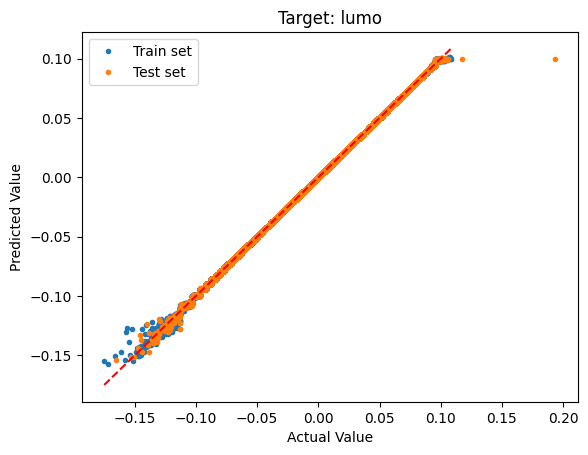

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.005103 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 765
[LightGBM] [Info] Number of data points in the train set: 107108, number of used features: 3
[LightGBM] [Info] Start training from score 0.251009


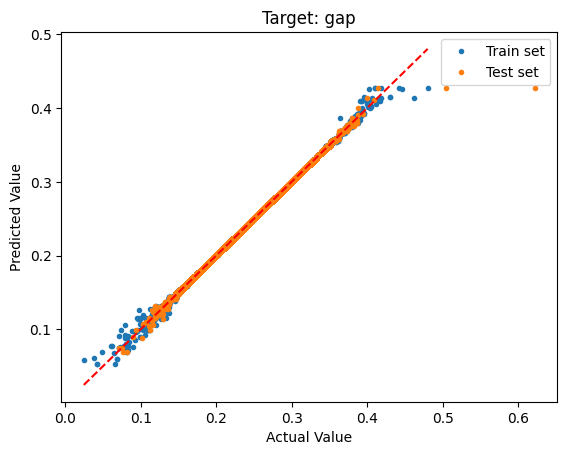

In [16]:
train, test = train_test_split(data,test_size=0.20)
targets = data.drop(columns=['A', 'B', 'C', 'mu', 'alpha', 'r2', 'zpve', 'u0',
       'u298', 'h298', 'g298', 'cv', 'u0_atom', 'u298_atom', 'h298_atom',
       'g298_atom'])
targets = targets.drop(targets.columns[0], axis=1)
property_names = targets.columns.tolist()
# print(targets)
# print(property_names)
for t in targets:
  train_X = train[property_names]
  train_y = train[t]
  test_X = test[property_names]
  test_y = test[t]

  lgbm = LGBMRegressor()
  lgbm.fit(train_X, train_y)

  test_pred = lgbm.predict(test_X)
  train_pred = lgbm.predict(train_X)

  plt.plot(train_y, train_pred,'.',label='Train set')
  plt.plot(test_y, test_pred,'.',label='Test set')
  # to get a diagonal line
  diagonal_line =np.linspace(np.min(train_y),np.max(train_y),1000)
  plt.plot(diagonal_line,diagonal_line, color='red', linestyle='--')
  # plt.axline([0, 0], slope=1, color='red', linestyle='--')
  plt.legend()
  plt.ylabel("Predicted Value")
  plt.xlabel("Actual Value")
  plt.title(f"Target: {t:s}")
  plt.show()

In [17]:
print("Number of node features", mol_gap_graphs[0].num_features)
print("Number of edge features", mol_gap_graphs[0].num_edge_features)

Number of node features 26
Number of edge features 18


In [18]:
#gap
for i, g in enumerate(mol_gap_graphs):
  if g.x.shape[1] != mol_gap_graphs[0].num_features:
    print(f"Issue with node features of graph {i}: {g}")
    print(g.x.shape)
    del mol_gap_graphs[i]

for i, g in enumerate(mol_gap_graphs):
  if g.edge_attr.shape[1] != mol_gap_graphs[0].num_edge_features:
    print(f"Issue with edge features of graph {i}: {g}")
    print(g.edge_attr.shape)
    del mol_gap_graphs[i]
#homo
for i, g in enumerate(mol_homo_graphs):
  if g.x.shape[1] != mol_homo_graphs[0].num_features:
    print(f"Issue with node features of graph {i}: {g}")
    print(g.x.shape)
    del mol_homo_graphs[i]

for i, g in enumerate(mol_homo_graphs):
  if g.edge_attr.shape[1] != mol_homo_graphs[0].num_edge_features:
    print(f"Issue with edge features of graph {i}: {g}")
    print(g.edge_attr.shape)
    del mol_homo_graphs[i]
#lumo
for i, g in enumerate(mol_lumo_graphs):
  if g.x.shape[1] != mol_lumo_graphs[0].num_features:
    print(f"Issue with node features of graph {i}: {g}")
    print(g.x.shape)
    del mol_lumo_graphs[i]

for i, g in enumerate(mol_lumo_graphs):
  if g.edge_attr.shape[1] != mol_lumo_graphs[0].num_edge_features:
    print(f"Issue with edge features of graph {i}: {g}")
    print(g.edge_attr.shape)
    del mol_lumo_graphs[i]

In [19]:
#@title Setup Subsets
from torch_geometric.loader import DataLoader
import random
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
random.shuffle(mol_gap_graphs)
random.shuffle(mol_homo_graphs)
random.shuffle(mol_lumo_graphs)

subset_size = None
batch_size = 128

if subset_size:
  mol_gap_graphs_used = random.sample(mol_gap_graphs, int(subset_size * len(mol_gap_graphs)))
  mol_homo_graphs_used = random.sample(mol_homo_graphs, int(subset_size * len(mol_homo_graphs)))
  mol_lumo_graphs_used = random.sample(mol_lumo_graphs, int(subset_size * len(mol_lumo_graphs)))
else:
  mol_gap_graphs_used = mol_gap_graphs
  mol_homo_graphs_used = mol_homo_graphs
  mol_lumo_graphs_used = mol_lumo_graphs

# data split
data_size = len(mol_gap_graphs_used)
print("Size of full data set: ",data_size)
print("Size of subset:",len(mol_gap_graphs_used))
train_index = int(data_size * 0.8)
test_index = train_index + int(data_size * 0.1)
val_index = test_index + int(data_size * 0.1)
print("Train index:",train_index)
print("Test index:",test_index)
print("Val index:",val_index)



# gap
train_loader_gap = DataLoader(mol_gap_graphs_used[0:train_index], batch_size=batch_size, shuffle=True)
test_loader_gap = DataLoader(mol_gap_graphs_used[train_index:test_index], batch_size=batch_size, shuffle=True)
val_loader_gap = DataLoader(mol_gap_graphs_used[test_index:val_index], batch_size=batch_size, shuffle=True)

from torch_geometric.loader import PrefetchLoader
train_loader_gap = PrefetchLoader(train_loader_gap, device=device)
val_loader_gap = PrefetchLoader(val_loader_gap, device=device)
test_loader_gap = PrefetchLoader(test_loader_gap, device=device)

# homo
train_loader_homo = DataLoader(mol_homo_graphs_used[0:train_index], batch_size=batch_size, shuffle=True)
test_loader_homo = DataLoader(mol_homo_graphs_used[train_index:test_index], batch_size=batch_size, shuffle=True)
val_loader_homo = DataLoader(mol_homo_graphs_used[test_index:val_index], batch_size=batch_size, shuffle=True)

from torch_geometric.loader import PrefetchLoader
train_loader_homo = PrefetchLoader(train_loader_homo, device=device)
val_loader_homo = PrefetchLoader(val_loader_homo, device=device)
test_loader_homo = PrefetchLoader(test_loader_homo, device=device)

# lumo
train_loader_lumo = DataLoader(mol_lumo_graphs_used[0:train_index], batch_size=batch_size, shuffle=True)
test_loader_lumo = DataLoader(mol_lumo_graphs_used[train_index:test_index], batch_size=batch_size, shuffle=True)
val_loader_lumo = DataLoader(mol_lumo_graphs_used[test_index:val_index], batch_size=batch_size, shuffle=True)

from torch_geometric.loader import PrefetchLoader
train_loader_lumo = PrefetchLoader(train_loader_lumo, device=device)
val_loader_lumo = PrefetchLoader(val_loader_lumo, device=device)
test_loader_lumo = PrefetchLoader(test_loader_lumo, device=device)

Size of full data set:  133885
Size of subset: 133885
Train index: 107108
Test index: 120496
Val index: 133884


In [20]:
import torch.nn.functional as Fun
from torch.nn import Linear, Sequential, BatchNorm1d, ReLU
from torch_geometric.nn import GCNConv, GINConv
from torch_geometric.loader import DataLoader
from torch_geometric.nn import global_mean_pool, global_add_pool

In [21]:
#@title Initialize the GIN
class GIN(torch.nn.Module):
    """Graph Isomorphism Network class with 3 GINConv layers and 2 linear layers"""

    def __init__(self, dim_input, dim_hidden):
        """Initializing GIN class

        Args:
            dim_hidden (int): the dimension of hidden layers
        """
        super(GIN, self).__init__()
        self.conv1 = GINConv(
            Sequential(Linear(dim_input, dim_hidden), BatchNorm1d(dim_hidden), ReLU(), Linear(dim_hidden, dim_hidden), ReLU())
        )
        self.conv2 = GINConv(
            Sequential(
                Linear(dim_hidden, dim_hidden), BatchNorm1d(dim_hidden), ReLU(), Linear(dim_hidden, dim_hidden), ReLU()
            )
        )
        self.conv3 = GINConv(
            Sequential(
                Linear(dim_hidden, dim_hidden), BatchNorm1d(dim_hidden), ReLU(), Linear(dim_hidden, dim_hidden), ReLU()
            )
        )
        self.lin1 = Linear(dim_hidden, dim_hidden)
        self.lin2 = Linear(dim_hidden, 1)

    def forward(self, data):
        x = data.x
        edge_index = data.edge_index
        batch = data.batch

        # Node embeddings
        h = self.conv1(x, edge_index)
        h = h.relu()
        h = self.conv2(h, edge_index)
        h = h.relu()
        h = self.conv3(h, edge_index)

        # Graph-level readout
        h = global_add_pool(h, batch)

        h = self.lin1(h)
        h = h.relu()
        h = Fun.dropout(h, p=0.5, training=self.training)
        h = self.lin2(h)

        return h

In [22]:
#@title Training Setup
def training(loader, model, loss, optimizer):
    """Training one epoch

    Args:
        loader (DataLoader): loader (DataLoader): training data divided into batches
        model (nn.Module): GNN model to train on
        loss (nn.functional): loss function to use during training
        optimizer (torch.optim): optimizer during training

    Returns:
        float: training loss
    """
    model.train()

    current_loss = 0
    for d in loader:
        optimizer.zero_grad()
        d.x = d.x.float()
        out = model(d)
        l = loss(out, torch.reshape(d.y, (len(d.y), 1)))
        current_loss += l / len(loader)
        l.backward()
        optimizer.step()
    return current_loss, model

@torch.no_grad()
def validation(loader, model, loss):
    """Validation

    Args:
        loader (DataLoader): validation set in batches
        model (nn.Module): current trained model
        loss (nn.functional): loss function

    Returns:
        float: validation loss
    """
    model.eval()
    val_loss = 0
    for d in loader:
        out = model(d)
        l = loss(out, torch.reshape(d.y, (len(d.y), 1)))
        val_loss += l / len(loader)
    return val_loss


@torch.no_grad()
def testing(loader, model):
    """Testing

    Args:
        loader (DataLoader): test dataset
        model (nn.Module): trained model

    Returns:
        float: test loss
    """
    loss = torch.nn.MSELoss()
    test_loss = 0
    test_target = numpy.empty((0))
    test_y_target = numpy.empty((0))
    for d in loader:
        out = model(d)
        l = loss(out, torch.reshape(d.y, (len(d.y), 1)))
        test_loss += l / len(loader)

        # save prediction vs ground truth values for plotting
        test_target = numpy.concatenate((test_target, out.detach().numpy()[:, 0]))
        test_y_target = numpy.concatenate((test_y_target, d.y.detach().numpy()))

    return test_loss, test_target, test_y_target


def train_epochs(epochs, learning_rate, model, train_loader, val_loader, file_path="best-model.pt"):
    import math
    import time
    """Training over all epochs

    Args:
        epochs (int): number of epochs to train for
        model (nn.Module): the current model
        train_loader (DataLoader): training data in batches
        val_loader (DataLoader): validation data in batches
        file_path (string): file to save the best model

    Returns:
        array: returning train and validation losses over all epochs
    """
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    loss = torch.nn.MSELoss()

    train_loss = np.empty(epochs)
    val_loss = np.empty(epochs)
    best_loss = math.inf

    start_time = time.perf_counter()

    for epoch in range(epochs):
        epoch_loss, model = training(train_loader, model, loss, optimizer)
        v_loss = validation(val_loader, model, loss)
        if v_loss < best_loss:
            torch.save(model.state_dict(), f"{file_path}")
            best_loss = v_loss
        train_loss[epoch] = epoch_loss.detach().cpu().numpy()
        val_loss[epoch] = v_loss.detach().cpu().numpy()


        if epoch % 2 == 0:
          current_time = time.perf_counter() - start_time
          average_time = current_time / (epoch + 1)
          print(
              f"Epoch: {epoch:2d}, Train loss: {epoch_loss.item():.4f} Val loss: {v_loss.item():.4f}, Average Time per epoch: {average_time:.2f}"
          )
    return train_loss, val_loss

def plot_loss(loss_history, loss_val_history):
  plt.plot(loss_val_history, label='Total - Validation set')
  plt.plot(loss_history, label='Total - Training set')

  plt.yscale('log')
  plt.legend()
  plt.ylabel("Loss")
  plt.xlabel("Epoch")
  plt.show()


def plot_target(model, train_loader, val_loader, test_loader=None):

  model.eval()

  train_pred = np.empty((0))
  train_true = np.empty((0))
  val_pred = np.empty((0))
  val_true = np.empty((0))
  test_pred = np.empty((0))
  test_true = np.empty((0))

  with torch.no_grad():
      for d in train_loader:
          out = model(d)
          train_pred = np.concatenate((train_pred, out.detach().cpu().numpy()[:, 0]))
          train_true = np.concatenate((train_true, d.y.detach().cpu().numpy()))
      for d in val_loader:
          out = model(d)
          val_pred = np.concatenate((val_pred, out.detach().cpu().numpy()[:, 0]))
          val_true = np.concatenate((val_true, d.y.detach().cpu().numpy()))
      if test_loader:
        for d in test_loader:
            out = model(d)
            test_pred = np.concatenate((test_pred, out.detach().cpu().numpy()[:, 0]))
            test_true = np.concatenate((test_true, d.y.detach().cpu().numpy()))


  plt.plot(train_pred,train_true,'.',label='Train set')
  plt.plot(val_pred,val_true,'.',label='Validation set')
  if test_loader:
    plt.plot(test_pred,test_true,'.',label='Test set')

  diagonal_line =np.linspace(np.min(train_true),np.max(train_true),1000)
  plt.plot(diagonal_line,diagonal_line, color='red', linestyle='--')

  plt.legend()
  plt.xlabel("Predicted Value")
  plt.ylabel("Actual Value")
  plt.show()

  plt.plot(train_pred,train_true-train_pred,'.',label='Train set')
  plt.plot(val_pred,val_true-val_pred,'.',label='Validation set')
  plt.plot(test_pred,test_true-test_pred,'.',label='Test set')
  plt.axhline(0, color='black', linewidth=1)
  plt.legend()
  plt.xlabel("Predicted Value")
  plt.ylabel("Residual (Actual-Predicted)")
  plt.show()

  sns.kdeplot(train_true-train_pred,label='Train set')
  sns.kdeplot(val_true-val_pred,label='Train set')
  sns.kdeplot(test_true-test_pred,label='Train set')
  plt.axvline(0, color='black', linewidth=1)
  plt.legend()
  plt.show()

In [23]:
dim_input = mol_gap_graphs[0].num_features
print(dim_input)

26


In [24]:
model_gap = GIN(dim_input,dim_hidden=128)
model_homo = GIN(dim_input,dim_hidden=128)
model_lumo = GIN(dim_input,dim_hidden=128)

print("Device: ", device)
model_gap.to(device)
model_homo.to(device)
model_lumo.to(device)

print(model_gap)
total_params = sum(p.numel() for p in model_gap.parameters())
print(f"\nTotal parameters: {total_params:,}\n")

Device:  cuda
GIN(
  (conv1): GINConv(nn=Sequential(
    (0): Linear(in_features=26, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=128, bias=True)
    (4): ReLU()
  ))
  (conv2): GINConv(nn=Sequential(
    (0): Linear(in_features=128, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=128, bias=True)
    (4): ReLU()
  ))
  (conv3): GINConv(nn=Sequential(
    (0): Linear(in_features=128, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=128, bias=True)
    (4): ReLU()
  ))
  (lin1): Linear(in_features=128, out_features=128, bias=True)
  (lin2): Linear(in_features=128, out_features=1, bias=True)
)



In [25]:
epochs = 50
learning_rate = 1e-3

gap_train_loss, gap_val_loss = train_epochs(
    epochs=epochs,
    learning_rate=learning_rate,
    model=model_gap,
    train_loader=train_loader_gap,
    val_loader=val_loader_gap,
    file_path="best-model-gap.pt"
)

homo_train_loss, homo_val_loss = train_epochs(
    epochs=epochs,
    learning_rate=learning_rate,
    model=model_homo,
    train_loader=train_loader_homo,
    val_loader=val_loader_homo,
    file_path="best-model-homo.pt"
)

lumo_train_loss, lumo_val_loss = train_epochs(
    epochs=epochs,
    learning_rate=learning_rate,
    model=model_lumo,
    train_loader=train_loader_lumo,
    val_loader=val_loader_lumo,
    file_path="best-model-lumo.pt"
)


Epoch:  0, Train loss: 0.0124 Val loss: 0.0005, Average Time per epoch: 11.85
Epoch:  2, Train loss: 0.0005 Val loss: 0.0003, Average Time per epoch: 10.75
Epoch:  4, Train loss: 0.0004 Val loss: 0.0002, Average Time per epoch: 10.66
Epoch:  6, Train loss: 0.0004 Val loss: 0.0003, Average Time per epoch: 10.61
Epoch:  8, Train loss: 0.0004 Val loss: 0.0002, Average Time per epoch: 10.54
Epoch: 10, Train loss: 0.0003 Val loss: 0.0002, Average Time per epoch: 10.53
Epoch: 12, Train loss: 0.0003 Val loss: 0.0002, Average Time per epoch: 10.53
Epoch: 14, Train loss: 0.0003 Val loss: 0.0002, Average Time per epoch: 10.45
Epoch: 16, Train loss: 0.0002 Val loss: 0.0001, Average Time per epoch: 10.44
Epoch: 18, Train loss: 0.0002 Val loss: 0.0002, Average Time per epoch: 10.41
Epoch: 20, Train loss: 0.0002 Val loss: 0.0001, Average Time per epoch: 10.40
Epoch: 22, Train loss: 0.0002 Val loss: 0.0001, Average Time per epoch: 10.43
Epoch: 24, Train loss: 0.0002 Val loss: 0.0001, Average Time per

KeyboardInterrupt: 

In [ ]:
plot_loss(gap_train_loss, gap_val_loss)
plot_loss(homo_train_loss, homo_val_loss)
plot_loss(lumo_train_loss, lumo_val_loss)

In [ ]:
plot_target(model_gap,train_loader_gap,val_loader_gap,test_loader_gap)
plot_target(model_homo,train_loader_homo,val_loader_homo,test_loader_homo)
plot_target(model_lumo,train_loader_lumo,val_loader_lumo,test_loader_lumo)

In [ ]:
torch.save(model_gap.state_dict(), "best-model-gap.pt")
torch.save(model_homo.state_dict(), "best-model-homo.pt")
torch.save(model_lumo.state_dict(), "best-model-lumo.pt")

In [ ]:
!ls